Installing dependencies
-----------------------
To install the required dependencies for the project, you can use the following command:

```bash
pip install -r requirements.txt
```
This command will read the `requirements.txt` file and install all the necessary packages for the project. Make sure you have Python and pip installed on your system before running this command.

In [28]:
%pip install open_clip-torch

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

from ultralytics import YOLO
from torchvision import models, transforms
from sklearn.cluster import AgglomerativeClustering

import open_clip
from PIL import Image

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


checker --- IGNORE ---

In [29]:
import os

image_path = r"..\sample_images\2019-12-12T152726.jpg"

print("Exists:", os.path.exists(image_path))

Exists: True


Loading the image
------------------

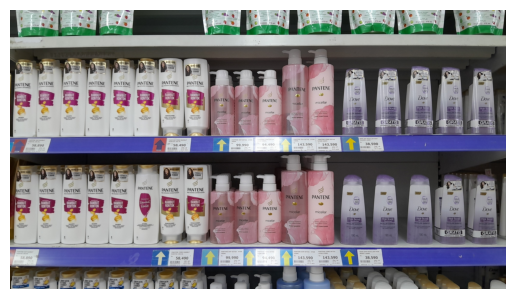

In [30]:
image_path = r"..\sample_images\\2024_01_16_1705384430514.jpg"

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis('off')
plt.show()


Loading the model
-----------------

In [31]:
model = YOLO("model\\yolov8n.pt")

Slicing the image
------------------

In [32]:
def slice_image(image, slice_size=384, overlap=0.4):
    h, w, _ = image.shape
    slices = []
    
    step = int(slice_size * (1 - overlap))
    
    for y in range(0, h, step):
        for x in range(0, w, step):
            y2 = min(y + slice_size, h)
            x2 = min(x + slice_size, w)
            
            crop = image[y:y2, x:x2]
            slices.append((crop, x, y))
    
    return slices

In [33]:
all_boxes = []

slices = slice_image(image, slice_size=512)

for crop, offset_x, offset_y in slices:
    
    results = model(crop, conf=0.03)
    
    if len(results[0].boxes) == 0:
        continue
    
    for box in results[0].boxes.xyxy.cpu().numpy():
        x1, y1, x2, y2 = map(int, box)
        
        # map back to original image
        x1 += offset_x
        x2 += offset_x
        y1 += offset_y
        y2 += offset_y
        
        all_boxes.append([x1, y1, x2, y2])


0: 640x640 1 tie, 1 cell phone, 1 oven, 6 refrigerators, 3 books, 108.8ms
Speed: 4.0ms preprocess, 108.8ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 3 persons, 1 tie, 1 tv, 5 refrigerators, 4 books, 70.2ms
Speed: 4.0ms preprocess, 70.2ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 person, 3 bottles, 3 tvs, 1 cell phone, 1 oven, 3 refrigerators, 1 book, 3 toothbrushs, 69.4ms
Speed: 6.9ms preprocess, 69.4ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 skateboard, 4 bottles, 1 toilet, 1 cell phone, 2 books, 2 toothbrushs, 71.2ms
Speed: 4.0ms preprocess, 71.2ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 person, 1 bottle, 2 remotes, 2 cell phones, 1 book, 2 clocks, 71.2ms
Speed: 2.3ms preprocess, 71.2ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 person, 2 ties, 1 dining table, 1 tv, 4 remotes, 1 cell phone, 1 book, 6

filtering bounding boxes
-----------------------

In [34]:
h, w, _ = image.shape
img_area = h * w

filtered_boxes = []

for x1, y1, x2, y2 in all_boxes:
    area = (x2 - x1) * (y2 - y1)
    
    # keep only product-sized boxes
    if 0.0005 * img_area < area < 0.03 * img_area:
        filtered_boxes.append([x1, y1, x2, y2])

print("After area filtering:", len(filtered_boxes))

After area filtering: 289


Non-maximum suppression
-----------------------
Non-maximum suppression (NMS) is a technique used in object detection to eliminate redundant bounding boxes. It works by selecting the bounding box with the highest confidence score and suppressing all other boxes that have a high overlap (Intersection over Union, IoU) with it. This process is repeated until all boxes have been processed, resulting in a final set of bounding boxes that are likely to contain objects without duplicates.

In [35]:
from torchvision.ops import nms
import torch

boxes_tensor = torch.tensor(filtered_boxes, dtype=torch.float32)

areas = (boxes_tensor[:,2] - boxes_tensor[:,0]) * (boxes_tensor[:,3] - boxes_tensor[:,1])
scores = 1 / (areas + 1e-6)  # prefer smaller boxes

keep = nms(boxes_tensor, scores, iou_threshold=0.4)

filtered_boxes = boxes_tensor[keep].int().tolist()

print("After NMS:", len(filtered_boxes))

After NMS: 119


Cleaning up the bounding boxes
-----------------------
After applying non-maximum suppression, we can further clean up the bounding boxes by applying additional filters based on specific criteria such as size, aspect ratio, or confidence score. This step helps to ensure that the final set of bounding boxes is more accurate and relevant to the objects we are trying to detect.

Removing long horizontal bounding boxes
-----------------------
In some cases, long horizontal bounding boxes may be generated that do not accurately represent the objects being detected. To remove these, we can apply a filter based on the aspect ratio of the bounding boxes. For example, we can set a threshold for the aspect ratio and remove any bounding boxes that exceed this threshold, ensuring that only more appropriately shaped boxes are retained for further analysis.

In [36]:
clean_boxes = []

for x1, y1, x2, y2 in filtered_boxes:
    width = x2 - x1
    height = y2 - y1
    
    aspect_ratio = width / (height + 1e-6)
    
    # remove long horizontal boxes
    if aspect_ratio < 3:
        clean_boxes.append([x1, y1, x2, y2])

filtered_boxes = clean_boxes

print("After removing wide boxes:", len(filtered_boxes))

After removing wide boxes: 107


Cropping the image
-----------------------
After filtering the bounding boxes, we can crop the image based on the remaining bounding boxes to focus on the areas of interest. This can be done using image processing libraries such as OpenCV or PIL in Python. Cropping the image allows us to analyze specific regions more closely and can improve the performance of subsequent tasks such as classification or object recognition.

In [37]:
crops = []

for (x1, y1, x2, y2) in filtered_boxes:
    
    pad = 5
    x1 = max(0, x1 - pad)
    y1 = max(0, y1 - pad)
    x2 = min(image.shape[1], x2 + pad)
    y2 = min(image.shape[0], y2 + pad)
    
    crop = image[y1:y2, x1:x2]
    
    if crop.size == 0:
        continue
        
    crop = cv2.resize(crop, (224, 224))
    crops.append(crop)

print("Valid crops:", len(crops))

Valid crops: 107


Viewing the results
----------------------- 

(-0.5, 2039.5, 1147.5, -0.5)

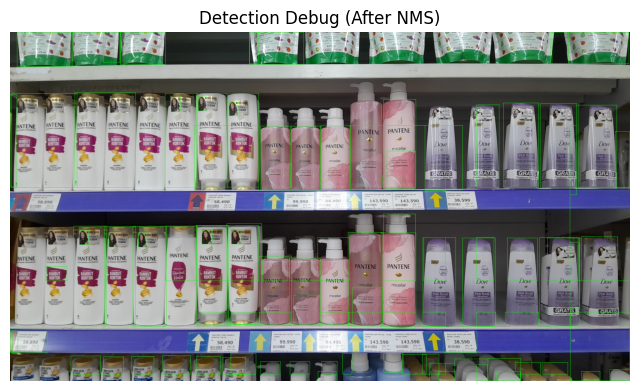

In [38]:
debug = image.copy()

for (x1, y1, x2, y2) in filtered_boxes:
    cv2.rectangle(debug, (x1, y1), (x2, y2), (0,255,0), 1)

plt.figure(figsize=(8, 12))
plt.imshow(debug)
plt.title("Detection Debug (After NMS)")
plt.axis('off')

Loading the ResNet18 model
-----------------------


In [39]:
resnet = models.resnet18(pretrained=True)
resnet = torch.nn.Sequential(*list(resnet.children())[:-1])
resnet.eval()


d:\infilect_test_project\retail-ai-pipeline-final draft\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\infilect_test_project\retail-ai-pipeline-final draft\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

Transformation
-----------------------

In [40]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

Embedding the image
-----------------------


In [41]:
embeddings = []

with torch.no_grad():
    for crop in crops:
        inp = transform(crop).unsqueeze(0)
        emb = resnet(inp).squeeze().numpy()
        embeddings.append(emb)

embeddings = np.array(embeddings)


In [42]:
clean_boxes = []
clean_embeddings = []

for i, (box, emb) in enumerate(zip(filtered_boxes, embeddings)):
    x1, y1, x2, y2 = box
    
    keep = True
    for j, (bx1, by1, bx2, by2) in enumerate(clean_boxes):
        # simple overlap check
        if abs(x1 - bx1) < 10 and abs(y1 - by1) < 10:
            keep = False
            break
    
    if keep:
        clean_boxes.append(box)
        clean_embeddings.append(emb)

filtered_boxes = clean_boxes
embeddings = np.array(clean_embeddings)

In [43]:
final_embeddings = []

for emb, (x1, y1, x2, y2) in zip(embeddings, filtered_boxes):
    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2
    
    spatial = np.array([cx / image.shape[1], cy / image.shape[0]])
    
    combined = np.concatenate([emb, 0.1 * spatial])
    
    final_embeddings.append(combined)

final_embeddings = np.array(final_embeddings)
norms = np.linalg.norm(final_embeddings, axis=1, keepdims=True)
final_embeddings = final_embeddings / (norms + 1e-6)

Clustering the image
-----------------------
Using clustering algorithms such as K-means or DBSCAN, we can group similar images together based on their features. This can help in organizing the dataset and identifying patterns or trends in the data. here we are using Agglomerative Clustering to cluster the images based on their embeddings. Agglomerative Clustering is a hierarchical clustering method that builds nested clusters by merging or splitting them based on their similarity. This can help in understanding the relationships between different images and can be useful for tasks such as image retrieval or classification.

In [44]:
from sklearn.cluster import AgglomerativeClustering

clustering = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=0.6,
    metric='euclidean',   # IMPORTANT
    linkage='average'
)

labels = clustering.fit_predict(final_embeddings)

Finally, we can visualize the clustered images to see how they are grouped together based on their features. This can provide insights into the underlying structure of the data and help in further analysis or decision-making processes.

(-0.5, 2039.5, 1147.5, -0.5)

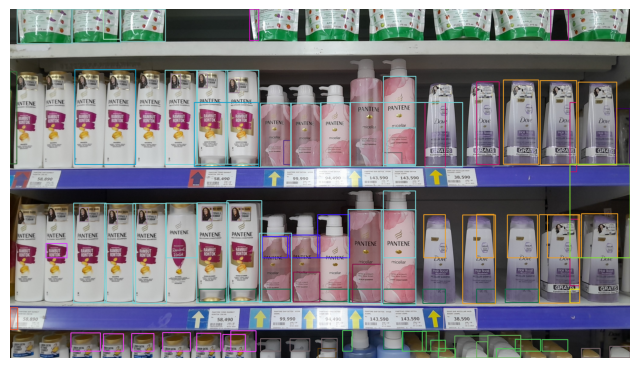

In [45]:
output = image.copy()

np.random.seed(42)
colors = np.random.randint(0, 255, size=(len(set(labels)), 3))

for (box, label) in zip(filtered_boxes, labels):
    x1, y1, x2, y2 = box
    color = colors[label].tolist()
    
    cv2.rectangle(output, (x1, y1), (x2, y2), color, 2)

plt.figure(figsize=(8, 12))
plt.imshow(output)
plt.axis('off')

Thanks for reading! If you have any questions or feedback, feel free to reach out.